# 10 - Phase 3: does the effect reverse? A power analysis that says no test is possible

Phase 2 split phase 1's -6.28% into roughly **-2.9% participation** and **-3.6%
redistribution**, but neither half cleared its own detection threshold. Phase 3 was designed
to sharpen that with a second experiment: seven states abolished their fees between
WS 2008/09 and WS 2014/15, and **if fees caused the fall, removing them should reverse it**.
A pre-existing trend does not flip sign when a policy does; a causal effect should.

The design is `DESIGN.md` section 15, committed to the repository as `b0c3575` **before any
phase 3 code was written**. This notebook builds the panel, validates the new volumes, and
computes the power the design requires before any effect is estimated.

**The answer is that the design cannot detect the reversal it was built to find.** The
minimum detectable effects are four to eight times larger than the effects to be reversed,
in both the primary and the secondary specification. Phase 3 therefore ends here as a
documented feasibility result rather than proceeding to estimation.

### Disclosure: the point estimates were seen before the power calculation

`DESIGN.md` 15.6 requires power to be computed before any effect is estimated. That order
was broken once, during development: a check that the not-yet-treated estimator executed on
the six-state sample printed the overall estimates, so they were seen before the minimum
detectable effect existed.

What limits the damage is that the full specification, including outcomes, comparison group,
window, the Baden-Wuerttemberg exclusion and the reading table, was committed as `b0c3575`
before that check ran, and **no part of it has been changed since**. The estimates are
printed at the end of this notebook, next to their MDEs, and are reported as uninformative.
Any design change made after seeing them would be indistinguishable from fitting the
specification to a result, which is why none is attempted.

In [1]:
import sys, itertools, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

def find_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "data" / "processed" / "panel.parquet").exists():
            return cand
    raise FileNotFoundError("panel.parquet not found. Run: py src/build_panel.py")

ROOT = find_root(); sys.path.insert(0, str(ROOT))
from src import fachserie as fsx
from src import estimation as est

# DESIGN.md 15.2: with no never-treated states in the primary sample, `differences`
# makes the last abolisher the comparison group and drops later periods. That is
# the intended design, explained in section 2 below, so this one warning is
# silenced. Every other warning is left visible.
warnings.filterwarnings("ignore", message="No never treated entities")

FIG = ROOT / "results" / "figures"; TAB = ROOT / "results" / "tables"
RAW = ROOT / "data" / "raw" / "fachserie"; TREAT = ROOT / "data" / "treatment"
plt.rcParams["figure.figsize"] = (11, 5.5)
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3

FIRST, LAST = 2007, 2015           # DESIGN.md 15.3
BW = "08"                           # excluded: abolition and double cohort both 2012
PHASE2 = {"attraction": -0.0367, "log_origin": -0.0295, "retention": -0.0060}
OUT = ["attraction", "log_origin", "retention"]
LABEL = {"attraction": "attraction", "log_origin": "participation", "retention": "retention"}

fees = pd.read_csv(TREAT / "fee_dates.csv", dtype={"state_code": str})
g8 = pd.read_csv(TREAT / "g8_dates.csv", dtype={"state_code": str})

VOLUMES = fsx.select_volumes(RAW, FIRST, LAST)
panel = fsx.build_panel(VOLUMES)
panel["abol"] = panel.state_code.map(fees.set_index("state_code")["abolish_year"])
panel["log_origin"] = np.log(panel.origin)

print(f"{len(VOLUMES)} volumes, WS {FIRST}/{str(FIRST+1)[-2:]} to WS {LAST}/{str(LAST+1)[-2:]}"
      f" ({sum(v.endswith('.xlsx') for v in VOLUMES)} in .xlsx)")
print(f"panel: {len(panel)} rows, {panel.state_code.nunique()} states")

9 volumes, WS 2007/08 to WS 2015/16 (3 in .xlsx)
panel: 144 rows, 16 states


## 1. Validation

The same three internal checks as phase 2, plus the external one: `study_location` against
`first_years_location` from GENESIS 21311-0014, now across the phase 3 years. Three of these
volumes are in `.xlsx` rather than `.xls`, since Destatis changed format from WS 2013/14, so
the check also confirms the format change altered nothing.

In [2]:
rows = []
for v in VOLUMES:
    fl, tot, ex, yr = fsx.read_matrix(v)
    r = fsx.validate(fl, tot, ex)
    rows.append({"year": yr, "format": Path(v).suffix, "Deutschland": int(r["germany_row"]),
                 "rows reconcile": r["rows_reconcile"],
                 "columns reconcile": r["columns_reconcile"],
                 "unattributed %": round(r["unattributed_share_pct"], 1)})
chk = pd.DataFrame(rows)
print(chk.to_string(index=False))

p1 = pd.read_parquet(ROOT / "data" / "processed" / "panel.parquet")
m = panel.merge(p1[["state_code", "year", "first_years_location"]],
                on=["state_code", "year"], how="inner")
gap = (m.study_location - m.first_years_location).abs()
print(f"\nagainst GENESIS 21311-0014: {len(m)} state-years, maximum gap {gap.max():.0f}")
ok = chk["rows reconcile"].all() and chk["columns reconcile"].all() and gap.max() == 0
print("verdict:", "all volumes reconcile, internally and against GENESIS" if ok
      else "FAILED - do not use")
assert ok
chk.to_csv(TAB / "10_extraction_checks.csv", index=False)

print(f"\nnational first-years: {chk.Deutschland.iloc[0]:,} in WS {FIRST}/08 to "
      f"{chk.Deutschland.max():,} at the peak, {100*(chk.Deutschland.max()/chk.Deutschland.iloc[0]-1):+.0f}%")

 year format  Deutschland  rows reconcile  columns reconcile  unattributed %
 2007   .xls       313540            True               True            13.0
 2008   .xls       345625            True               True            13.0
 2009   .xls       369273            True               True            12.8
 2010   .xls       386921            True               True            13.4
 2011   .xls       445320            True               True            12.4
 2012   .xls       427825            True               True            14.4
 2013  .xlsx       438913            True               True            15.3
 2014  .xlsx       432280            True               True            16.1
 2015  .xlsx       432589            True               True            17.3

against GENESIS 21311-0014: 144 state-years, maximum gap 0
verdict: all volumes reconcile, internally and against GENESIS

national first-years: 313,540 in WS 2007/08 to 445,320 at the peak, +42%


## 2. The two specifications, and what the estimator does with them

**Primary** (`DESIGN.md` 15.2): the seven fee states minus Baden-Wuerttemberg, compared with
fee states **not yet** abolished. The right counterfactual, and every unit is western, so the
east-west confound disappears.

**Secondary**: the same six plus the nine never-treated states. More power and continuity with
phases 1 and 2, at the cost of reintroducing east-west.

One consequence of the primary design was predicted in 15.2 and is confirmed here. With no
never-treated units, the estimator uses the last cohort as the comparison group and drops
every period from that cohort's date onward.

In [3]:
primary = panel[panel.abol.notna() & (panel.state_code != BW)].copy()
secondary = panel[panel.state_code != BW].copy()
secondary["treatment_year_cs"] = secondary["abol"]

coh = primary.drop_duplicates("state_code").set_index("state")["abol"].astype(int).sort_values()
print("primary sample, abolition cohort by state:")
print(coh.to_string())
last = coh.max()
print(f"\n{coh.idxmax()} abolishes last ({last}) and becomes the comparison group for all others.")
print(f"effective primary window: WS {FIRST}/{str(FIRST+1)[-2:]} to WS {last-1}/{str(last)[-2:]}"
      f" ({last-FIRST} periods), not {LAST-FIRST+1}")

print("\nnot-yet-treated controls available to each cohort at its abolition year:")
for st, c in coh.items():
    if c == last: continue
    n = int((coh > c).sum())
    print(f"  {st:22s} {c}: {n}")

print(f"\nsecondary sample: {secondary.state_code.nunique()} states, "
      f"{int(secondary.groupby('state_code').abol.first().notna().sum())} treated")

primary sample, abolition cohort by state:
state
Hessen                 2008
Saarland               2010
Nordrhein-Westfalen    2011
Hamburg                2012
Bayern                 2013
Niedersachsen          2014

Niedersachsen abolishes last (2014) and becomes the comparison group for all others.
effective primary window: WS 2007/08 to WS 2013/14 (7 periods), not 9

not-yet-treated controls available to each cohort at its abolition year:
  Hessen                 2008: 5
  Saarland               2010: 4
  Nordrhein-Westfalen    2011: 3
  Hamburg                2012: 2
  Bayern                 2013: 1

secondary sample: 15 states, 6 treated


### The fast estimators are verified before use

Exact enumeration refits the primary estimator 720 times, and the secondary 2 000 times per
outcome. Both use closed forms in `src/estimation.py`, checked here against the package. Only
point estimates come from them.

In [4]:
check = []
for y in OUT:
    pkg_p = float(est.cs_overall(primary, y, cohort_col="abol",
                                 control_group="not_yet_treated")["ATT"].iloc[0])
    pkg_s = float(est.cs_overall(secondary, y, cohort_col="abol")["ATT"].iloc[0])
    check.append({"outcome": LABEL[y],
                  "primary diff": abs(pkg_p - est.cs_overall_nyt_fast(primary, y)),
                  "secondary diff": abs(pkg_s - est.cs_overall_fast(secondary, y,
                                                                    cohort_col="abol"))})
ck = pd.DataFrame(check)
print(ck.to_string(index=False, float_format=lambda x: f"{x:.2e}"))
assert (ck[["primary diff", "secondary diff"]] < 1e-8).all().all(), "fast path mismatch"
print("\nboth closed forms reproduce the package exactly")

      outcome  primary diff  secondary diff
   attraction      6.94e-18        2.06e-18
participation      0.00e+00        0.00e+00
    retention      3.47e-18        0.00e+00

both closed forms reproduce the package exactly


## 3. Minimum detectable effect

The primary specification has six units with six distinct abolition dates, so there are
exactly 720 ways to assign the dates. **Every one is enumerated**, rather than sampled. The
minimum detectable effect is 2.8 times the standard deviation of the estimator across those
assignments, which is its sampling noise under the hypothesis of no effect.

This uses the realised data, so any real abolition effect is spread across the permutations
and inflates the spread. **The MDE is therefore conservative.** Section 4 shows that halving
it would not change the conclusion.

The threshold that matters is the reversal to be detected: phase 2's -3.6% on attraction and
-2.9% on participation.

In [5]:
codes = sorted(primary.state_code.unique())
dates = primary.drop_duplicates("state_code").set_index("state_code").abol.reindex(codes).to_numpy()
assignments = sorted(set(itertools.permutations(dates)))
print(f"distinct assignments: {len(assignments)} | smallest achievable p-value: "
      f"{1/len(assignments):.4f}")

scodes = sorted(secondary.state_code.unique())
svals = secondary.drop_duplicates("state_code").set_index("state_code").abol.reindex(scodes).to_numpy()
rng = np.random.default_rng(42)
sec_perms = [rng.permutation(svals) for _ in range(2000)]

rows = []
for y in OUT:
    x = primary.copy(); d_p = []
    for a in assignments:
        x["abol"] = x.state_code.map(dict(zip(codes, a)))
        d_p.append(est.cs_overall_nyt_fast(x, y))
    xs = secondary.copy(); d_s = []
    for a in sec_perms:
        xs["abol"] = xs.state_code.map(dict(zip(scodes, a)))
        d_s.append(est.cs_overall_fast(xs, y, cohort_col="abol"))
    for spec, dr in (("primary, not-yet-treated", d_p), ("secondary, never-treated", d_s)):
        mde = 2.8 * np.std(dr, ddof=1)
        target = abs(PHASE2[y])
        rows.append({"spec": spec, "outcome": LABEL[y], "MDE": mde,
                     "reversal to detect": target, "MDE / target": mde / target})
pw = pd.DataFrame(rows)
print(pw.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
pw.to_csv(TAB / "10_power.csv", index=False)
print("\nAn MDE / target ratio above 1 means the design cannot see a full reversal.")

distinct assignments: 720 | smallest achievable p-value: 0.0014
                    spec       outcome       MDE  reversal to detect  MDE / target
primary, not-yet-treated    attraction    0.1530              0.0367        4.1682
secondary, never-treated    attraction    0.1626              0.0367        4.4315
primary, not-yet-treated participation    0.2029              0.0295        6.8787
secondary, never-treated participation    0.3059              0.0295       10.3690
primary, not-yet-treated     retention    0.0581              0.0060        9.6883
secondary, never-treated     retention    0.0437              0.0060        7.2872

An MDE / target ratio above 1 means the design cannot see a full reversal.


## 4. Why: the period, not the specification

The same outcomes, with the same state and year fixed effects, are far noisier across
2007 to 2015 than across phase 2's 2003 to 2007. The abolitions fell in the most turbulent
stretch German higher education had seen in decades: the Hochschulpakt expansion, the end of
conscription in 2011, rising internationalisation, and G8 double cohorts in most states.

      outcome  resid SD 2003-2007  resid SD 2007-2015     ratio
   attraction              0.0384              0.0829    2.1559
participation              0.0332              0.1481    4.4571

participation residuals, mean absolute size:
  double-cohort state-years : 0.1837  (10 of 135)
  all other state-years     : 0.1184

Double cohorts are noisier, but the rest of the window is too, so dropping them
would not restore phase 2's precision. The noise belongs to the period.


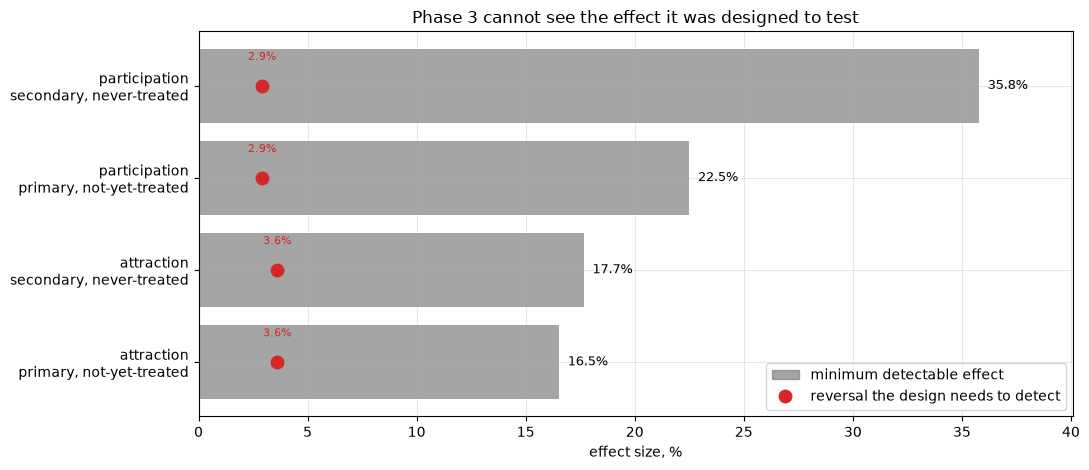

In [6]:
# each window is read once: the .xlsx volumes are slow to parse
p2 = fsx.build_panel(fsx.select_volumes(RAW, 2003, 2007))
p2["log_origin"] = np.log(p2.origin)
p3 = panel[panel.state_code != BW].copy()

def resid_sd(p, y):
    r = smf.ols(f"{y} ~ C(state_code) + C(year)", data=p).fit().resid
    return float(np.std(r, ddof=1)), p.assign(resid=r.values)

rows = []
for y in ("attraction", "log_origin"):
    a, _ = resid_sd(p2, y)
    b, _ = resid_sd(p3, y)
    rows.append({"outcome": LABEL[y], "resid SD 2003-2007": a,
                 "resid SD 2007-2015": b, "ratio": b / a})
nz = pd.DataFrame(rows)
print(nz.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
nz.to_csv(TAB / "10_window_noise.csv", index=False)

_, p = resid_sd(p3, "log_origin")
dc = g8.set_index("state_code").double_abitur_year
p["double_cohort"] = [yr == dc.get(sc) for sc, yr in zip(p.state_code, p.year)]
print(f"\nparticipation residuals, mean absolute size:")
print(f"  double-cohort state-years : {p.loc[p.double_cohort, 'resid'].abs().mean():.4f}"
      f"  ({int(p.double_cohort.sum())} of {len(p)})")
print(f"  all other state-years     : {p.loc[~p.double_cohort, 'resid'].abs().mean():.4f}")
print("\nDouble cohorts are noisier, but the rest of the window is too, so dropping them")
print("would not restore phase 2's precision. The noise belongs to the period.")

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# plotted in percent so the chart matches the README and the summary tables
plot = pw[pw.outcome.isin(["attraction", "participation"])].copy()
plot["mde_pct"] = 100 * (np.exp(plot.MDE) - 1)
plot["target_pct"] = 100 * (1 - np.exp(-plot["reversal to detect"]))
plot["label"] = plot.outcome + "\n" + plot.spec

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.barh(plot.label, plot.mde_pct, color="tab:grey", alpha=0.7)
ax.plot(plot.target_pct, plot.label, "o", color="tab:red", ms=9)
for y, (m, t) in enumerate(zip(plot.mde_pct, plot.target_pct)):
    ax.text(m + 0.4, y, f"{m:.1f}%", va="center", fontsize=9)
    ax.text(t, y + 0.28, f"{t:.1f}%", ha="center", fontsize=8, color="tab:red")
ax.legend(handles=[Patch(color="tab:grey", alpha=0.7, label="minimum detectable effect"),
                   Line2D([], [], marker="o", color="tab:red", ls="",
                          ms=9, label="reversal the design needs to detect")],
          loc="lower right")
ax.set_xlabel("effect size, %")
ax.set_xlim(0, plot.mde_pct.max() * 1.12)
ax.set_title("Phase 3 cannot see the effect it was designed to test")
plt.tight_layout()
plt.savefig(FIG / "23_phase3_power.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. The point estimates, reported as uninformative

Printed for completeness and transparency, since they were seen before the power calculation
(see the disclosure at the top). Every one sits well inside its minimum detectable effect, so
**none of them is evidence of anything**, including the ones that happen to point in the
direction of a reversal. No inference is attached, deliberately: a p-value on an estimate this
far below its MDE would invite exactly the over-reading the design exists to prevent.

In [7]:
rows = []
for y in OUT:
    a_p = est.cs_overall_nyt_fast(primary, y)
    a_s = est.cs_overall_fast(secondary, y, cohort_col="abol")
    for spec, a in (("primary, not-yet-treated", a_p), ("secondary, never-treated", a_s)):
        mde = float(pw[(pw.spec == spec) & (pw.outcome == LABEL[y])].MDE.iloc[0])
        rows.append({"spec": spec, "outcome": LABEL[y], "estimate": a, "MDE": mde,
                     "within MDE": "yes, uninformative" if abs(a) < mde else "NO"})
est_t = pd.DataFrame(rows)
print(est_t.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
est_t.to_csv(TAB / "10_estimates_uninformative.csv", index=False)
print("\nReading, per DESIGN.md 15.7: no reversal detected, and read against section 3,")
print("this is not evidence that the introduction effect was spurious. The design could")
print("not have seen a reversal of the size phase 2 implies.")

                    spec       outcome  estimate       MDE         within MDE
primary, not-yet-treated    attraction    0.0510    0.1530 yes, uninformative
secondary, never-treated    attraction    0.0007    0.1626 yes, uninformative
primary, not-yet-treated participation   -0.0543    0.2029 yes, uninformative
secondary, never-treated participation    0.1414    0.3059 yes, uninformative
primary, not-yet-treated     retention    0.0139    0.0581 yes, uninformative
secondary, never-treated     retention    0.0165    0.0437 yes, uninformative

Reading, per DESIGN.md 15.7: no reversal detected, and read against section 3,
this is not evidence that the introduction effect was spurious. The design could
not have seen a reversal of the size phase 2 implies.


## What this notebook establishes

**Phase 3 cannot answer its question. The minimum detectable effect is four to ten times
larger than the reversal it was designed to detect, in both specifications, because the
abolitions fell in the noisiest period German higher education had seen in decades. No
reversal is detected, and that is not evidence against phases 1 and 2.**

### 1. The data is sound

All nine volumes reconcile internally with zero residual, including the three in `.xlsx`
format from WS 2013/14 onward. Against GENESIS 21311-0014, `study_location` matches
`first_years_location` in all **144 state-years with a maximum gap of 0**. The format change
altered nothing, and phase 3 stands on the same verified footing as phases 1 and 2.

### 2. The primary design shrinks further than planned

With no never-treated units, the estimator makes Niedersachsen, the last abolisher in 2014,
the comparison group for every other state and drops every period from 2014 onward. The
effective window is **WS 2007/08 to WS 2013/14, seven periods rather than nine**. The control
pool shrinks with each abolition: five states for Hessen in 2008, down to **one** for Bayern
in 2013. This was predicted in `DESIGN.md` 15.2 and is confirmed here.

### 3. The power calculation, by exact enumeration

All 720 possible assignments of the six abolition dates were computed, so the primary
specification's power rests on enumeration rather than sampling. The secondary used 2 000
permutations.

| specification | outcome | MDE | reversal to detect | ratio |
|---|---|---|---|---|
| primary, not-yet-treated | attraction | 0.153 (16.5%) | 0.037 | 4.2 |
| secondary, never-treated | attraction | 0.163 (17.7%) | 0.037 | 4.4 |
| primary, not-yet-treated | participation | 0.203 (22.5%) | 0.030 | 6.9 |
| secondary, never-treated | participation | 0.306 (35.8%) | 0.030 | 10.4 |
| primary, not-yet-treated | retention | 0.058 | 0.006 | 9.7 |
| secondary, never-treated | retention | 0.044 | 0.006 | 7.3 |

Every ratio is above four. The permutation spread is computed on realised data and is
therefore conservative, but halving every MDE would still leave all six above their target.
The smallest achievable p-value from exact enumeration is 1/720, about 0.0014, so the limit
is not the number of permutations but the noise in each one.

### 4. The cause is the period

With identical outcomes and identical state and year fixed effects, the residual standard
deviation across 2007 to 2015 is **2.2 times** phase 2's on attraction and **4.5 times** on
participation. National first-years rose 42 percent between WS 2007/08 and the 2011 peak,
conscription ended in 2011, and the unattributable share climbed from 13.0 to 17.3 percent.

Double cohorts contribute but do not explain it: participation residuals average 0.184 in the
ten double-cohort state-years against 0.118 in the rest, and 0.118 is itself more than three
times phase 2's level. Excluding them would not restore the lost precision. The noise belongs
to the whole window.

### 5. The point estimates, reported as uninformative

All six sit inside their minimum detectable effects. Some point toward a reversal (primary
attraction +0.051) and some away from one (primary participation -0.054); the two
specifications disagree with each other on participation by nearly 0.2. That disagreement
is itself a sign of how little the estimates carry. As disclosed at the top of the notebook,
they were seen once before the power calculation; the committed specification was not changed
afterwards, and no inference is attached.

### Conclusion

Under the reading rule fixed in `DESIGN.md` 15.7, **no reversal is detected**, and read
against section 3 this is not evidence that the introduction effect was spurious: the design
could not have seen a reversal of the size phase 2 implies. Phase 2's decomposition stands as
it was, neither confirmed nor weakened.

The binding constraint is units, not years. More years would not help, since the primary
design has no controls left after 2014 and later years add the Schleswig-Holstein double
cohort, the G9 reversals and COVID. Enrolment at university or district level, turning
sixteen states into hundreds of units, is what would make the test possible.
